# 感知机 (Rosenblatt, 1957)

## 1. 问题设定

二分类数据集：
$$
\mathcal{D} = \{(\mathbf{x}^{(1)}, y^{(1)}), (\mathbf{x}^{(2)}, y^{(2)}), \dots, (\mathbf{x}^{(N)}, y^{(N)})\}
$$
- $\mathbf{x}^{(i)} \in \mathbb{R}^n$：特征向量
- $y^{(i)} \in \{-1, +1\}$：标签

目标：找到超平面 $\mathbf{w}^T \mathbf{x} + b = 0$ 正确分开两类。

## 2. 感知机模型

输出函数：
$$
\hat{y} = f(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^T \mathbf{x} + b)
$$
其中符号函数：
$$
\operatorname{sign}(z) = \begin{cases}
+1 & \text{if } z \ge 0 \\
-1 & \text{if } z < 0
\end{cases}
$$

## 3. 学习算法（原始形式）

### 3.1 损失函数

误分类点条件：
$$
y^{(i)}(\mathbf{w}^T \mathbf{x}^{(i)} + b) \le 0
$$
即 真实值与预测值**异号**

损失函数（所有误分类点）：
$$
L(\mathbf{w}, b) = -\sum_{\mathbf{x}^{(i)} \in M} y^{(i)} (\mathbf{w}^T \mathbf{x}^{(i)} + b)
$$


### 3.2 随机梯度下降

对单个误分类点 $(\mathbf{x}^{(i)}, y^{(i)})$ 有损失函数：
$$
L^{(i)}(\mathbf{w}, b) = -y^{(i)}(\mathbf{w}^T \mathbf{x}^{(i)} + b)
$$

梯度：
$$
\nabla_{\mathbf{w}} L^{(i)} = -y^{(i)} \mathbf{x}^{(i)}, \quad 
\frac{\partial L^{(i)}}{\partial b} = -y^{(i)}
$$

更新规则（学习率 $\eta$）：
$$
\mathbf{w} \leftarrow \mathbf{w} - \eta (-y^{(i)} \mathbf{x}^{(i)}) = \mathbf{w} + \eta y^{(i)} \mathbf{x}^{(i)}
$$
$$
b \leftarrow b - \eta (-y^{(i)}) = b + \eta y^{(i)}
$$

通常取 $\eta = 1$，得到经典感知机更新：
$$
\boxed{\mathbf{w} \leftarrow \mathbf{w} + y^{(i)} \mathbf{x}^{(i)}},\quad 
\boxed{b \leftarrow b + y^{(i)}}
$$

## 4. 收敛性定理（Novikoff 定理）

### 前提假设

1. **线性可分**：存在 $(\mathbf{w}^*, b^*)$ 使得对所有 $i$：
   $$
   y^{(i)}(\mathbf{w}^{*T} \mathbf{x}^{(i)} + b^*) \ge \gamma > 0
   $$
   $\gamma$ 为间隔（margin）。

2. **数据有界**：存在 $R > 0$ 使得 $\|\mathbf{x}^{(i)}\| \le R$。

### 定理内容

令 $k$ 为感知机算法在训练过程中的更新次数，则：
$$
k \le \left( \frac{R}{\gamma} \right)^2
$$

### 证明思路（增广向量）

将偏置合并进权重：$\bar{\mathbf{w}} = [\mathbf{w}; b]$，$\bar{\mathbf{x}} = [\mathbf{x}; 1]$。更新规则变为：
$$
\bar{\mathbf{w}}_{k+1} = \bar{\mathbf{w}}_k + y^{(i)} \bar{\mathbf{x}}^{(i)}
$$

- 内积下界：$\bar{\mathbf{w}}^* \cdot \bar{\mathbf{w}}_k \ge k \gamma$
- 范数上界：$\|\bar{\mathbf{w}}_k\|^2 \le k R^2$

结合 Cauchy-Schwarz 不等式：
$$
\|\bar{\mathbf{w}}^*\| \|\bar{\mathbf{w}}_k\| \ge \bar{\mathbf{w}}^* \cdot \bar{\mathbf{w}}_k \implies k \le \left(\frac{R}{\gamma}\right)^2
$$

## 5. 局限性与意义

- **只能处理线性可分问题**（如 XOR 不可分）
- **解不唯一**，依赖初始值和样本顺序
- 但它是神经网络的基础，开创了机器学习可自动学习模式的先河。


## 6. 实现

### 导入所需库(numpy, matplotlib)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

### 定义感知机类

In [ ]:

class Perceptron:
    """原始感知机(Rosenblatt, 1957)"""
    
    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.errors = []  # 记录每轮误分类样本数
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # 初始化权重和偏置为 0
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_epochs):
            error_count = 0
            for idx, x_i in enumerate(X):
                # 线性输出
                linear = np.dot(x_i, self.weights) + self.bias
                # 阶跃函数预测（标签为 0/1）
                y_pred = 1 if linear >= 0 else 0
                
                # 更新规则（仅当预测错误时）
                update = self.lr * (y[idx] - y_pred)
                if update != 0:
                    self.weights += update * x_i
                    self.bias += update
                    error_count += 1
            self.errors.append(error_count)
            # 全部正确分类，提前停止
            if error_count == 0:
                break
        return self
    
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return np.where(linear >= 0, 1, 0)

### 生成随机的训练数据并可视化

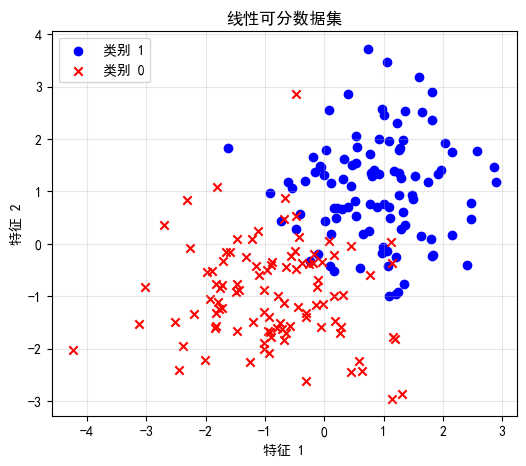

In [ ]:
# 生成两类点，分别在直线 x + y = 0 两侧
np.random.seed(42)
n_samples = 200

# 第一类：分布在 (1, 1) 附近，标签 1
X1 = np.random.randn(n_samples // 2, 2) + np.array([1, 1])
# 第二类：分布在 (-1, -1) 附近，标签 0
X2 = np.random.randn(n_samples // 2, 2) + np.array([-1, -1])

X = np.vstack([X1, X2])
y = np.hstack([np.ones(n_samples // 2), np.zeros(n_samples // 2)])

# 打乱顺序
shuffle_idx = np.random.permutation(n_samples)
X, y = X[shuffle_idx], y[shuffle_idx]

# 可视化数据
plt.figure(figsize=(6, 5))
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='o', label='类别 1')
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='x', label='类别 0')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.title('线性可分数据集')
plt.grid(alpha=0.3)
plt.show()

### 训练感知机模型

In [ ]:
p = Perceptron(learning_rate = 0.1, n_epochs = 200)
p.fit(X, y)

# 输出最终参数
print(f"训练完成， 权重 = {p.weights}, 偏置 = {p.bias:.4f}")
print(f"总迭代轮数：{len(p.errors)}")

训练完成， 权重 = [0.09925696 0.16246081], 偏置 = 0.0000
总迭代轮数：200


### 绘制误差下降曲线

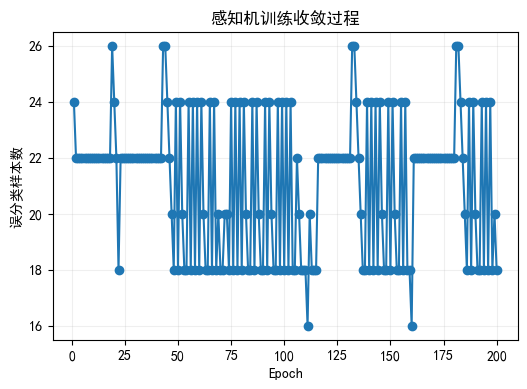

In [ ]:
# 误差下降曲线
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(p.errors) + 1), p.errors, marker='o')
plt.xlabel('Epoch')
plt.ylabel('误分类样本数')
plt.title('感知机训练收敛过程')
plt.grid(alpha=0.2)
plt.show()

### 决策边界可视化

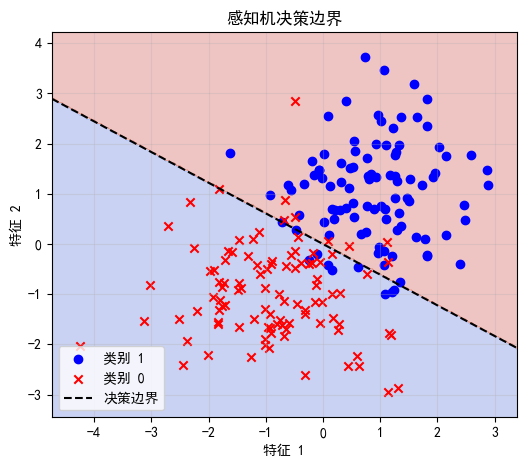

In [ ]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # 预测整个网格
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='o', label='类别 1')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='x', label='类别 0')
    
    # 画出权重决定的直线 w1*x1 + w2*x2 + b = 0
    if model.weights[1] != 0:
        x_vals = np.array([x_min, x_max])
        y_vals = -(model.weights[0] * x_vals + model.bias) / model.weights[1]
        plt.plot(x_vals, y_vals, 'k--', label='决策边界')
    
    plt.xlabel('特征 1')
    plt.ylabel('特征 2')
    plt.legend()
    plt.title('感知机决策边界')
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(p, X, y)

### XOR 不可分演示

In [ ]:
# 构建 XOR 数据
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# 训练感知机
p_xor = Perceptron(learning_rate=0.1, n_epochs=100)
p_xor.fit(X_xor, y_xor)

print(f"XOR 训练结束，误分类数序列: {p_xor.errors}")
print("→ 感知机无法收敛，因为数据不是线性可分的")

XOR 训练结束，误分类数序列: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
→ 感知机无法收敛，因为数据不是线性可分的
